In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import shapiro, probplot
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')


In [20]:
# Đọc dữ liệu từ file CSV 
train_df = pd.read_csv("food_consumption_1214.csv", sep=',')
test_df = pd.read_csv("food_consumption_1416.csv", sep=',')
display(train_df.head(), test_df.head())


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,inpatient_cost,insurance_premium,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thunhap,actual_food_14
0,10010000400815,1,5,1,33,NaN,1,2.0,500.0,0.0,NaN,NaN,2.0,2.0,500,0,0.0,343000,27163.0
1,10010002802514,1,5,2,60,NaN,1,1.0,120.0,0.0,NaN,209.0,1.0,2.0,500,0,125.0,162525,14542.0
2,10020006701613,1,5,1,51,NaN,1,1.0,550.0,0.0,NaN,150.0,2.0,2.0,700,0,0.0,235290,9611.0
3,10040013903013,1,1,1,52,NaN,1,NaN,NaN,NaN,NaN,NaN,2.0,2.0,200,50,0.0,186000,2740.0
4,10050016703013,1,2,1,63,NaN,1,2.0,0.0,0.0,NaN,NaN,1.0,2.0,300,1050,0.0,519700,7351.5


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,inpatient_cost,insurance_premium,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thunhap,actual_food_16
0,10010000400815,1,5,1,35,1,1,3.0,1310.0,0.0,NaN,290.0,2.0,2.0,980,150,0,592600.0,24578.0
1,10010002802514,1,5,2,63,1,1,1.0,600.0,0.0,NaN,290.0,2.0,2.0,1500,200,150,225650.0,11518.0
2,10020006701613,1,5,1,53,1,1,1.0,950.0,0.0,NaN,350.0,2.0,2.0,870,100,0,281894.0,7707.0
3,10040013903013,1,1,1,54,1,1,NaN,NaN,NaN,NaN,NaN,2.0,2.0,300,0,0,114500.0,4821.0
4,10050016703013,1,2,1,65,25,1,2.0,600.0,0.0,NaN,NaN,2.0,2.0,100,30,0,368180.0,5480.7


In [21]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            1635 non-null   int64  
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1211 non-null   float64
 8   outpatient_cost       1100 non-null   float64
 9   inpatient_visits      1211 non-null   float64
 10  inpatient_cost        387 non-null    float64
 11  insurance_premium     849 non-null    float64
 12  insurance_outpatient  1507 non-null   float64
 13  insurance_inpatient   1507 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [22]:
train_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1635 entries, 0 to 1634
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   h_code                1635 non-null   int64  
 1   tinh                  1635 non-null   int64  
 2   household_size        1635 non-null   int64  
 3   head_gender           1635 non-null   int64  
 4   head_age              1635 non-null   int64  
 5   area_type1            3 non-null      float64
 6   area_type2            1635 non-null   int64  
 7   outpatient_visits     1229 non-null   float64
 8   outpatient_cost       1124 non-null   float64
 9   inpatient_visits      1229 non-null   float64
 10  inpatient_cost        416 non-null    float64
 11  insurance_premium     807 non-null    float64
 12  insurance_outpatient  1464 non-null   float64
 13  insurance_inpatient   1464 non-null   float64
 14  medicine_cost         1635 non-null   int64  
 15  equipment_cost       

In [23]:
test_df.isnull().sum()

h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1                 0
area_type2                 0
outpatient_visits        424
outpatient_cost          535
inpatient_visits         424
inpatient_cost          1248
insurance_premium        786
insurance_outpatient     128
insurance_inpatient      128
medicine_cost              0
equipment_cost             0
health_subsidy             0
thunhap                    0
actual_food_16             0
dtype: int64

In [24]:
train_df.isnull().sum()

h_code                     0
tinh                       0
household_size             0
head_gender                0
head_age                   0
area_type1              1632
area_type2                 0
outpatient_visits        406
outpatient_cost          511
inpatient_visits         406
inpatient_cost          1219
insurance_premium        828
insurance_outpatient     171
insurance_inpatient      171
medicine_cost              0
equipment_cost             0
health_subsidy             0
thunhap                    0
actual_food_14             0
dtype: int64

In [25]:
# Định nghĩa cột cần xử lý
numerical_cols = ['outpatient_visits', 'outpatient_cost', 'inpatient_visits', 
                  'inpatient_cost', 'insurance_premium', 'area_type1']
categorical_cols = ['insurance_outpatient', 'insurance_inpatient']

print("\n[Xử lý biến số - Numerical]")
for col in numerical_cols:
    if col in train_df.columns and col in test_df.columns:
        #  Tính mean từ TRAIN
        mean_val = train_df[col].mean()
        
        # Áp dụng cho cả train và test
        train_missing = train_df[col].isnull().sum()
        test_missing = test_df[col].isnull().sum()
        
        train_df[col].fillna(mean_val, inplace=True)
        test_df[col].fillna(mean_val, inplace=True)
        
        print(f"   {col:25s} | mean={mean_val:10.2f} | train_missing={train_missing:4d} | test_missing={test_missing:4d}")

print("\n[Xử lý biến phân loại - Categorical]")
for col in categorical_cols:
    if col in train_df.columns and col in test_df.columns:
        # Tính mode từ TRAIN
        modes = train_df[col].mode()
        mode_val = modes.iloc[0] if not modes.empty else 0
        
        train_missing = train_df[col].isnull().sum()
        test_missing = test_df[col].isnull().sum()
        
        train_df[col].fillna(mode_val, inplace=True)
        test_df[col].fillna(mode_val, inplace=True)
        
        print(f"   {col:25s} | mode={mode_val:10.0f} | train_missing={train_missing:4d} | test_missing={test_missing:4d}")



[Xử lý biến số - Numerical]
   outpatient_visits         | mean=      2.66 | train_missing= 406 | test_missing= 424
   outpatient_cost           | mean=   1005.86 | train_missing= 511 | test_missing= 535
   inpatient_visits          | mean=      0.27 | train_missing= 406 | test_missing= 424
   inpatient_cost            | mean=   5149.35 | train_missing=1219 | test_missing=1248
   insurance_premium         | mean=    312.38 | train_missing= 828 | test_missing= 786
   area_type1                | mean=     64.67 | train_missing=1632 | test_missing=   0

[Xử lý biến phân loại - Categorical]
   insurance_outpatient      | mode=         2 | train_missing= 171 | test_missing= 128
   insurance_inpatient       | mode=         2 | train_missing= 171 | test_missing= 128


In [26]:
summary_test = test_df.describe(include='all')
summary_train = train_df.describe(include='all')
display(summary_test, summary_train)

,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,inpatient_cost,insurance_premium,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thunhap,actual_food_16
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.793884,1.236697,51.395107,45.476453,1.014679,2.563808,989.862842,0.264950,5116.628135,356.096643,1.751070,1.923547,816.387156,56.911927,737.585321,1.110556e+05,4841.603547
std,2.775770e+14,27.488299,1.565685,0.425185,13.925109,26.949177,0.147703,2.997272,2927.912839,0.572193,5205.857901,157.077725,0.432525,0.265802,1828.829267,275.759382,4087.083086,1.323976e+05,4606.518367
min,1.001000e+13,1.000000,1.000000,1.000000,16.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3.530000e+03,376.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,41.000000,26.000000,1.000000,1.000000,120.000000,0.000000,5149.353365,290.000000,2.000000,2.000000,200.000000,0.000000,0.000000,4.708200e+04,2470.000000
50%,4.445519e+14,44.000000,4.000000,1.000000,50.000000,40.000000,1.000000,2.000000,680.000000,0.000000,5149.353365,312.380421,2.000000,2.000000,360.000000,0.000000,0.000000,8.345000e+04,3800.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,59.500000,68.000000,1.000000,2.662327,1005.861210,0.269325,5149.353365,312.380421,2.000000,2.000000,720.000000,50.000000,0.000000,1.377930e+05,5969.000000
max,9.697332e+14,96.000000,13.000000,2.000000,97.000000,99.000000,3.000000,48.000000,72000.000000,7.000000,95000.000000,3000.000000,2.000000,2.000000,35000.000000,8690.000000,105000.000000,2.646980e+06,92958.000000


,h_code,tinh,household_size,head_gender,head_age,area_type1,area_type2,outpatient_visits,outpatient_cost,inpatient_visits,inpatient_cost,insurance_premium,insurance_outpatient,insurance_inpatient,medicine_cost,equipment_cost,health_subsidy,thunhap,actual_food_14
count,1.635000e+03,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.00000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1.635000e+03,1635.000000
mean,4.776141e+14,47.285015,3.883180,1.220183,49.781651,64.666667,1.012232,2.662327,1005.86121,0.269325,5149.353365,312.380421,1.695413,1.907645,589.521713,40.614067,941.909480,9.129448e+04,4484.486361
std,2.775770e+14,27.488299,1.491036,0.414497,14.079010,0.828156,0.125547,3.634870,4090.73000,0.601840,7530.480938,138.252709,0.460373,0.289615,1553.856805,127.679769,6898.575419,9.572851e+04,3761.977140
min,1.001000e+13,1.000000,1.000000,1.000000,20.000000,51.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,3.400000e+03,360.000000
25%,2.523708e+14,25.000000,3.000000,1.000000,40.000000,64.666667,1.000000,1.000000,100.00000,0.000000,5149.353365,265.000000,1.000000,2.000000,100.000000,0.000000,0.000000,3.949450e+04,2311.500000
50%,4.445519e+14,44.000000,4.000000,1.000000,48.000000,64.666667,1.000000,2.000000,550.00000,0.000000,5149.353365,312.380421,2.000000,2.000000,250.000000,0.000000,0.000000,7.108500e+04,3558.000000
75%,7.271026e+14,72.000000,5.000000,1.000000,58.000000,64.666667,1.000000,2.662327,1005.86121,0.269325,5149.353365,312.380421,2.000000,2.000000,500.000000,30.000000,295.000000,1.141320e+05,5460.000000
max,9.697332e+14,96.000000,11.000000,2.000000,95.000000,92.000000,3.000000,60.000000,125000.00000,12.000000,200000.000000,2500.000000,2.000000,2.000000,27000.000000,2000.000000,200000.000000,2.339000e+06,55787.000000


In [27]:
# Mã hóa biến định tính bằng LabelEncoder
le = LabelEncoder()
for col in ['tinh', 'head_gender', 'area_type2', 'insurance_outpatient', 'insurance_inpatient']:
    le.fit(train_df[col])
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    
    
print("\nPhân phối biến mục tiêu actual_food_14:")
print(train_df['actual_food_14'].describe())
print("\nPhân phối biến mục tiêu actual_food_16:")
print(test_df['actual_food_16'].describe())


Phân phối biến mục tiêu actual_food_14:
count     1635.000000
mean      4484.486361
std       3761.977140
min        360.000000
25%       2311.500000
50%       3558.000000
75%       5460.000000
max      55787.000000
Name: actual_food_14, dtype: float64

Phân phối biến mục tiêu actual_food_16:
count     1635.000000
mean      4841.603547
std       4606.518367
min        376.000000
25%       2470.000000
50%       3800.000000
75%       5969.000000
max      92958.000000
Name: actual_food_16, dtype: float64



Số features ban đầu: 17
Features: ['tinh', 'household_size', 'head_gender', 'head_age', 'area_type1', 'area_type2', 'outpatient_visits', 'outpatient_cost', 'inpatient_visits', 'inpatient_cost', 'insurance_premium', 'insurance_outpatient', 'insurance_inpatient', 'medicine_cost', 'equipment_cost', 'health_subsidy', 'thunhap']

[Training RF để tính feature importance]

 TOP 10 FEATURES QUAN TRỌNG NHẤT:
         Variable  Importance
          thunhap    0.438028
             tinh    0.089185
         head_age    0.080860
    medicine_cost    0.068547
insurance_premium    0.068251
  outpatient_cost    0.051564
   household_size    0.046588
outpatient_visits    0.044501
   equipment_cost    0.031532
   health_subsidy    0.026731


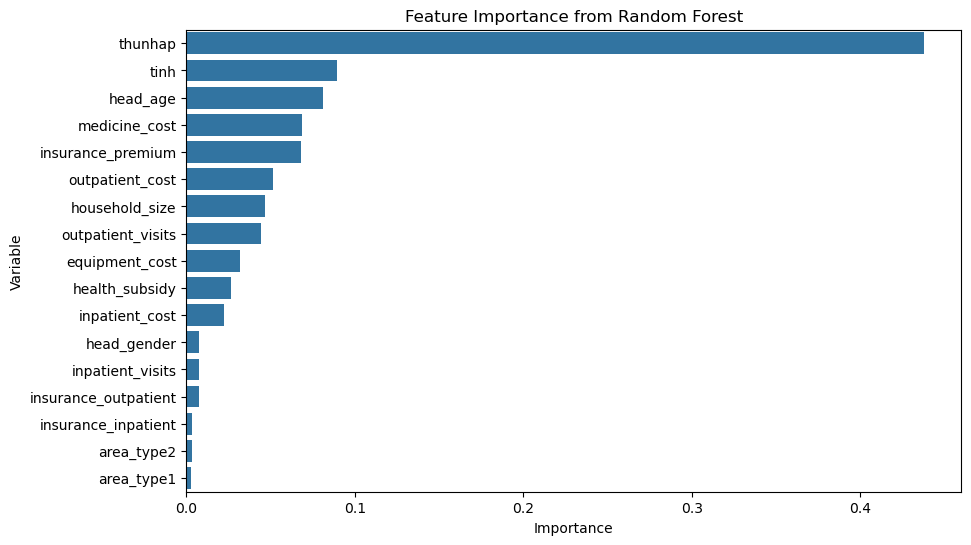


 Số features được chọn (importance > 0.05): 6
 Các features: ['thunhap', 'tinh', 'head_age', 'medicine_cost', 'insurance_premium', 'outpatient_cost']

 Train shape sau feature selection: (1635, 7)
 Test shape sau feature selection: (1635, 7)


In [28]:
# Chuẩn bị dữ liệu train để feature selection
X_full_train = train_df.drop(['actual_food_14', 'h_code'], axis=1, errors='ignore')
y_train = train_df['actual_food_14'].copy()

print(f"\nSố features ban đầu: {X_full_train.shape[1]}")
print(f"Features: {list(X_full_train.columns)}")

# Train Random Forest để đánh giá feature importance
print("\n[Training RF để tính feature importance]")
rf_selector = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_full_train, y_train)

# Lấy feature importance
feature_importance = pd.DataFrame({
    'Variable': X_full_train.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n TOP 10 FEATURES QUAN TRỌNG NHẤT:")
print(feature_importance.head(10).to_string(index=False))

# Vẽ biểu đồ tầm quan trọng của các đặc trưng
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=feature_importance)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.show()

# Chọn features có importance > threshold
importance_threshold = 0.05 
important_features = feature_importance[
    feature_importance['Importance'] > importance_threshold
]['Variable'].tolist()

print(f"\n Số features được chọn (importance > {importance_threshold}): {len(important_features)}")
print(f" Các features: {important_features}")

# ÁP DỤNG LÊN CẢ TRAIN VÀ TEST
train_df_selected = train_df[important_features + ['actual_food_14']].copy()
test_df_selected = test_df[important_features + ['actual_food_16']].copy()

print(f"\n Train shape sau feature selection: {train_df_selected.shape}")
print(f" Test shape sau feature selection: {test_df_selected.shape}")


KIỂM TRA PHÂN PHỐI CHUẨN (TRƯỚC LOG TRANSFORMATION)
Số biến liên tục: 6



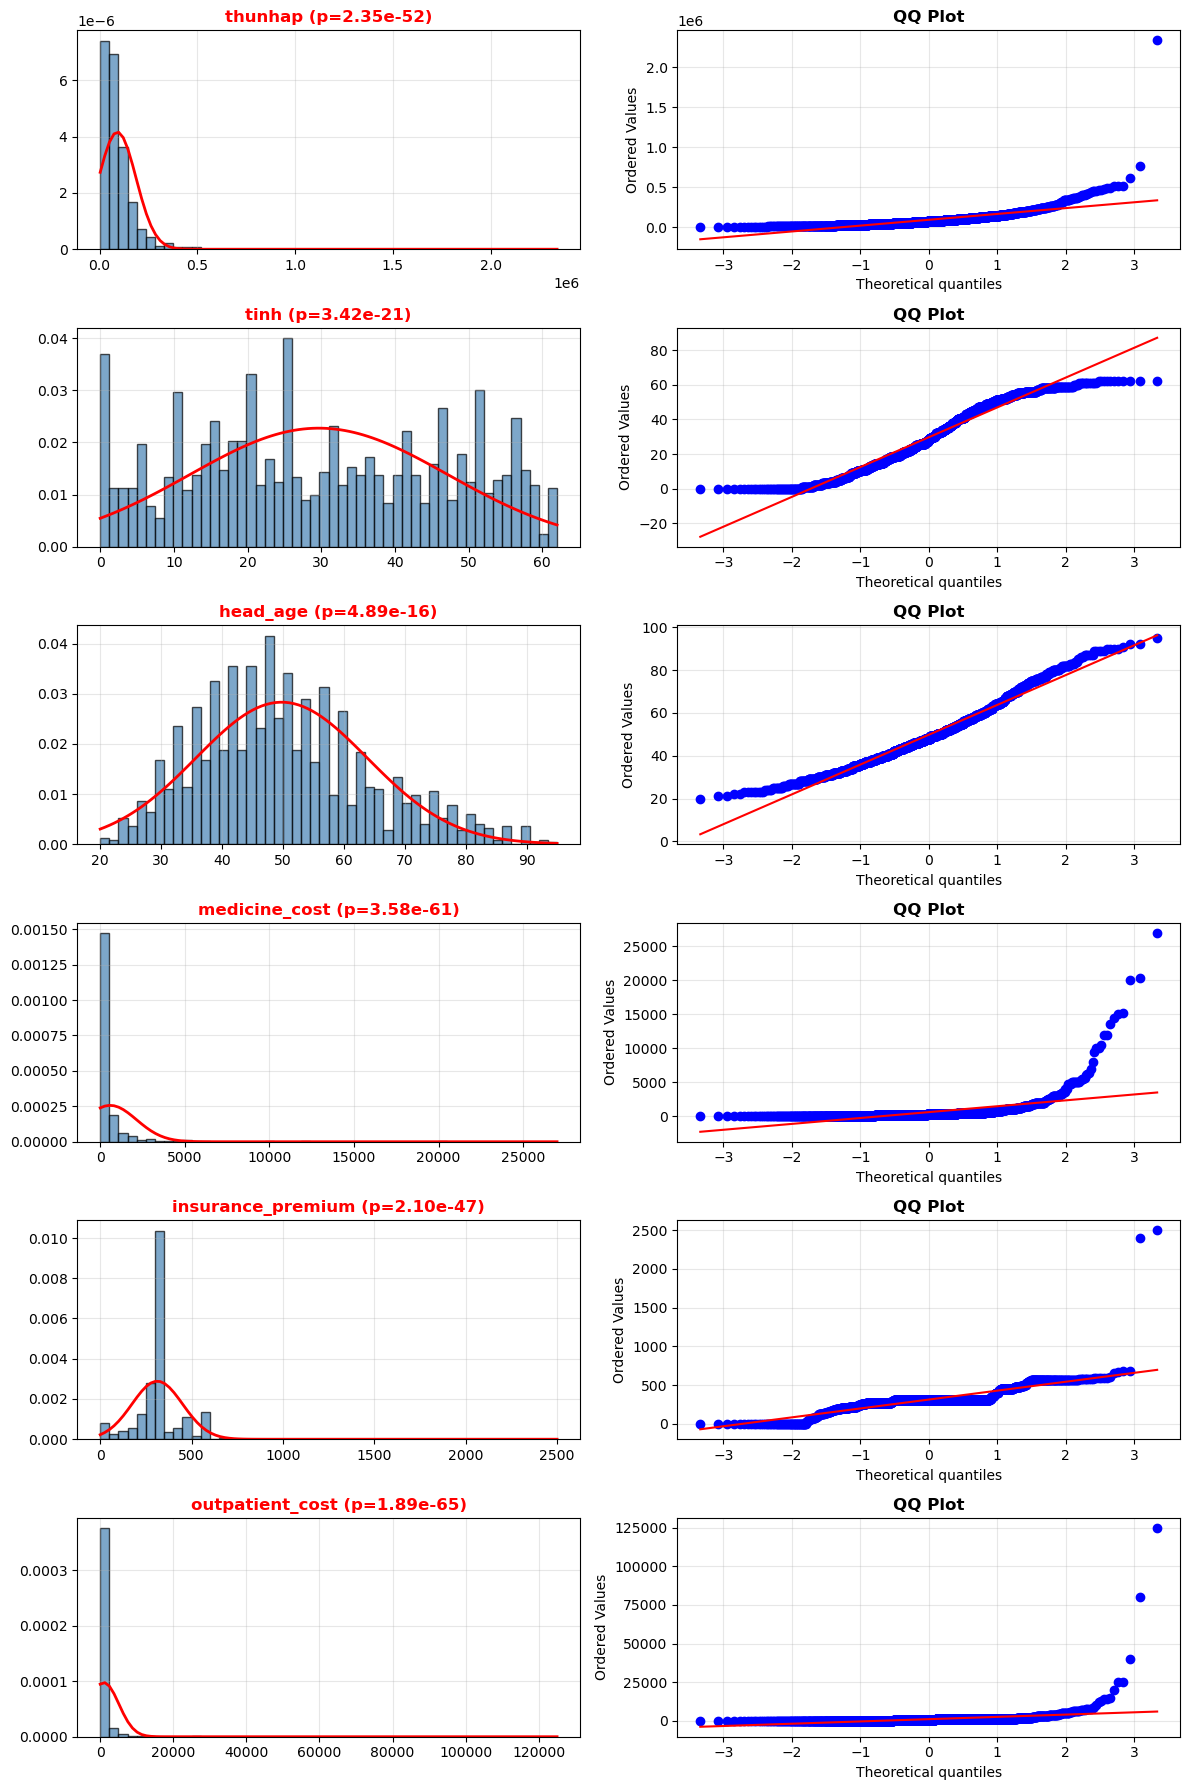


          Feature      P-value  Skewness
  outpatient_cost 1.890409e-65 22.437156
    medicine_cost 3.576238e-61  8.803960
          thunhap 2.350176e-52  9.262761
insurance_premium 2.100922e-47  4.521814
             tinh 3.421869e-21  0.059995
         head_age 4.885911e-16  0.549529

Kết quả: 0/6 biến phân phối chuẩn
→ Các biến không chuẩn cần log transformation



In [29]:
print("KIỂM TRA PHÂN PHỐI CHUẨN (TRƯỚC LOG TRANSFORMATION)")

# Xác định biến liên tục
continuous_cols = [col for col in train_df_selected.drop('actual_food_14', axis=1).columns 
                   if train_df_selected[col].nunique() > 15]

print(f"Số biến liên tục: {len(continuous_cols)}\n")

# Tạo figure
n_features = len(continuous_cols)
n_cols = 2  # Histogram và QQ plot
n_rows = n_features
fig = plt.figure(figsize=(12, 3 * n_rows))

# Kiểm tra từng biến
results = []
for idx, col in enumerate(continuous_cols):
    data = train_df_selected[col].dropna()
    stat, p_value = shapiro(data)
    skew = stats.skew(data)
    
    results.append({
        'Feature': col,
        'P-value': p_value,
        'Skewness': skew
    })
    
    # Histogram
    ax1 = plt.subplot(n_rows, n_cols, idx * n_cols + 1)
    ax1.hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
    ax1.set_title(f'{col} (p={p_value:.2e})', fontweight='bold', 
                  color='green' if p_value >= 0.05 else 'red')
    ax1.grid(True, alpha=0.3)
    
    # QQ plot
    ax2 = plt.subplot(n_rows, n_cols, idx * n_cols + 2)
    stats.probplot(data, dist="norm", plot=ax2)
    ax2.set_title(f'QQ Plot', fontweight='bold')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bảng kết quả
df_results = pd.DataFrame(results).sort_values('P-value')
print("\n" + df_results.to_string(index=False))

# Số biến phân phối chuẩn (p-value >= 0.05)
n_normal = int((df_results['P-value'] >= 0.05).sum())

print(f"\nKết quả: {n_normal}/{len(continuous_cols)} biến phân phối chuẩn")
print("→ Các biến không chuẩn cần log transformation\n")


In [30]:
def safe_log_transform_fit(series, col_name):
    if (series <= 0).any():
        min_val = series.min()
        shift_val = -min_val + 1
        print(f"   {col_name} → Shift by {shift_val}")
        return shift_val
    return 0

def safe_log_transform_apply(series, shift_val):
    if shift_val > 0:
        return np.log(series + shift_val)
    return np.log(series)
# Xác định biến liên tục (nhiều hơn 15 unique values)
continuous_features = []
for col in important_features:
    if train_df_selected[col].nunique() > 15:
        continuous_features.append(col)

for col in continuous_features:
    shift_val = safe_log_transform_fit(train_df_selected[col], col)
    
    # TRANSFORM cả train và test với CÙNG shift value
    train_df_selected[f'log_{col}'] = safe_log_transform_apply(
        train_df_selected[col], shift_val
    )
    test_df_selected[f'log_{col}'] = safe_log_transform_apply(
        test_df_selected[col], shift_val
    )
    # Xóa cột gốc
    train_df_selected.drop(columns=[col], inplace=True)
    test_df_selected.drop(columns=[col], inplace=True)
    
    print(f"  Tạo cột mới: log_{col}")

print(f"   Train shape: {train_df_selected.shape}")
print(f"   Test shape: {test_df_selected.shape}")


  Tạo cột mới: log_thunhap
   tinh → Shift by 1
  Tạo cột mới: log_tinh
  Tạo cột mới: log_head_age
   medicine_cost → Shift by 1
  Tạo cột mới: log_medicine_cost
   insurance_premium → Shift by 1.0
  Tạo cột mới: log_insurance_premium
   outpatient_cost → Shift by 1.0
  Tạo cột mới: log_outpatient_cost
   Train shape: (1635, 7)
   Test shape: (1635, 7)


KIỂM TRA PHÂN PHỐI SAU LOG TRANSFORMATION
Số biến đã log: 6



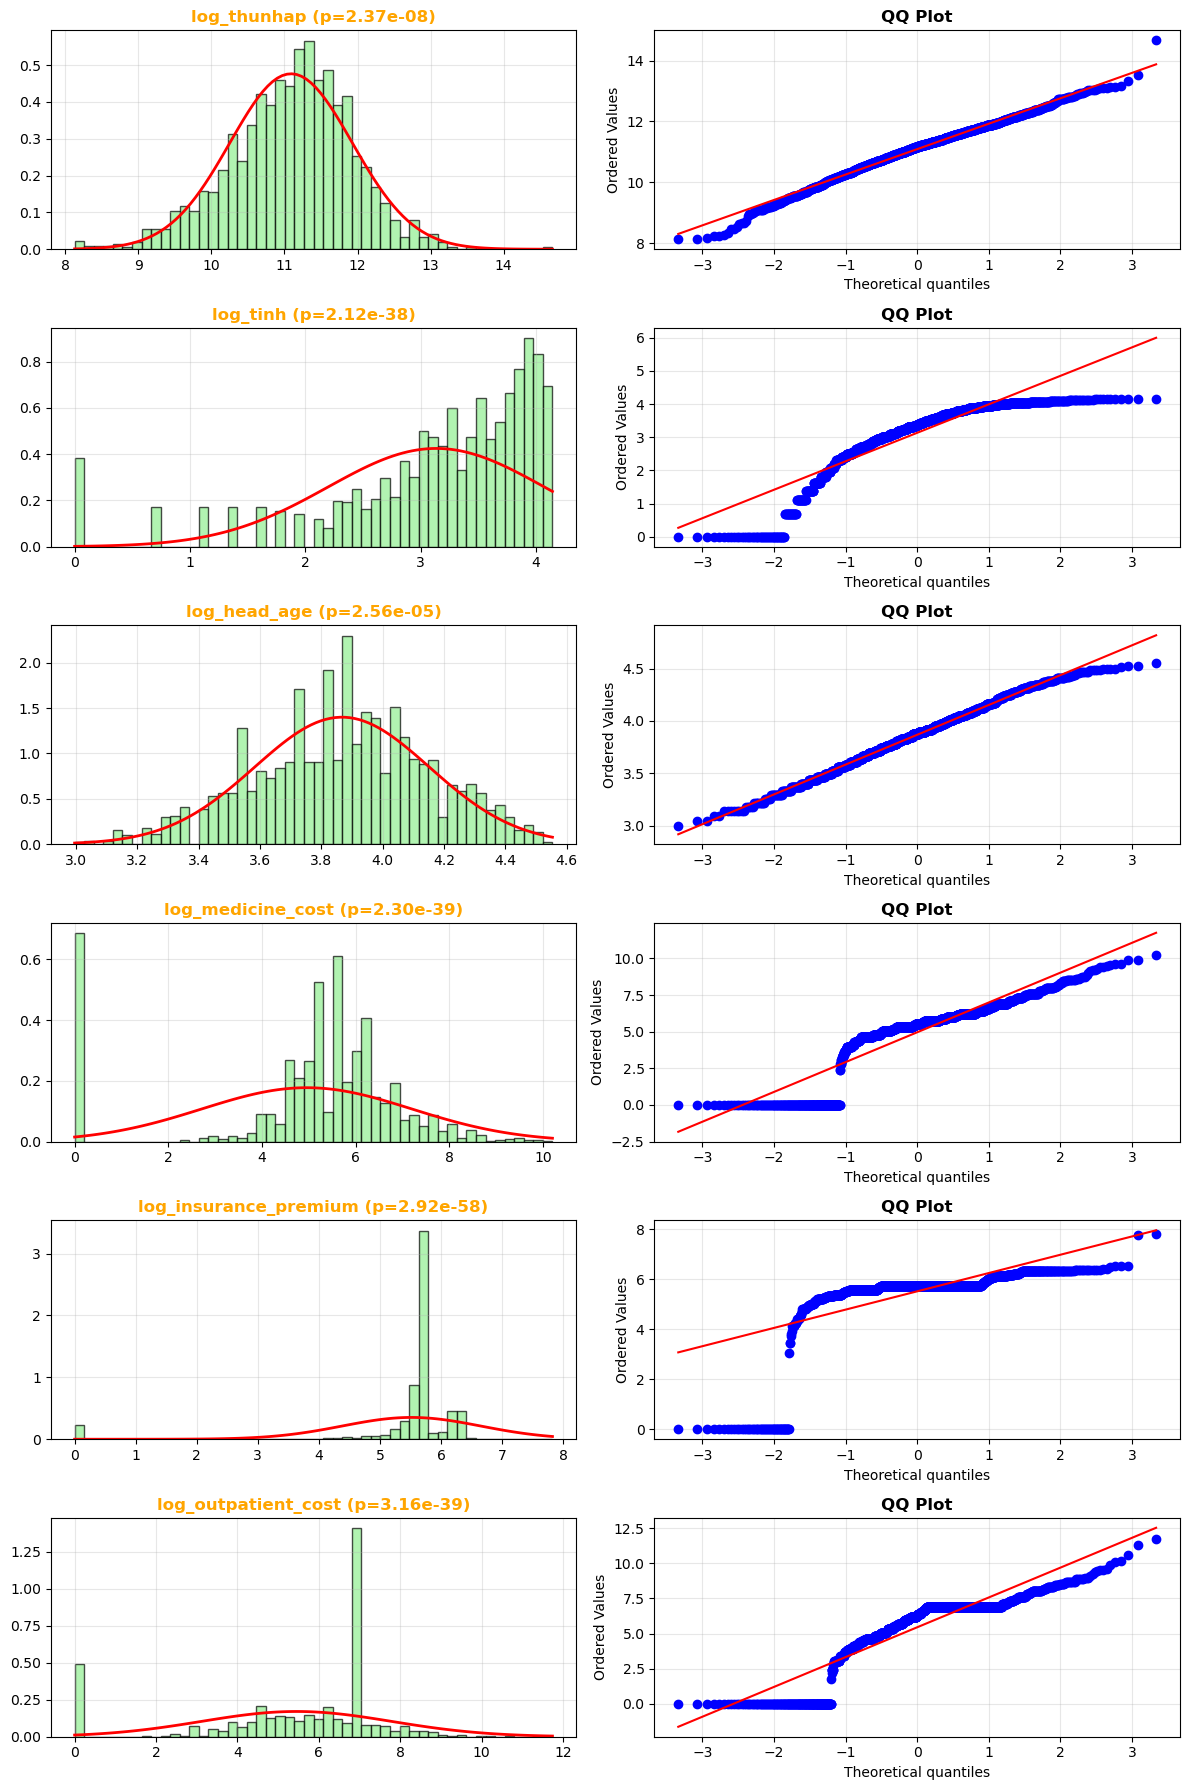


              Feature      P-value  Skewness
log_insurance_premium 2.920639e-58 -4.218425
    log_medicine_cost 2.295902e-39 -1.199921
  log_outpatient_cost 3.156301e-39 -1.238921
             log_tinh 2.115537e-38 -1.609583
          log_thunhap 2.367678e-08 -0.328179
         log_head_age 2.561370e-05 -0.141015


In [31]:
print("KIỂM TRA PHÂN PHỐI SAU LOG TRANSFORMATION")

# Lấy các cột log
log_cols = [col for col in train_df_selected.columns if col.startswith('log_')]
print(f"Số biến đã log: {len(log_cols)}\n")

# Tạo figure
n_features = len(log_cols)
n_cols = 2
n_rows = n_features
fig = plt.figure(figsize=(12, 3 * n_rows))

# Kiểm tra từng biến
results = []
for idx, col in enumerate(log_cols):
    data = train_df_selected[col].dropna()
    stat, p_value = shapiro(data)
    skew = stats.skew(data)
    
    results.append({
        'Feature': col,
        'P-value': p_value,
        'Skewness': skew
    })
    
    # Histogram
    ax1 = plt.subplot(n_rows, n_cols, idx * n_cols + 1)
    ax1.hist(data, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
    ax1.set_title(f'{col} (p={p_value:.2e})', fontweight='bold',
                  color='green' if p_value >= 0.05 else 'orange')
    ax1.grid(True, alpha=0.3)
    
    # QQ plot
    ax2 = plt.subplot(n_rows, n_cols, idx * n_cols + 2)
    stats.probplot(data, dist="norm", plot=ax2)
    ax2.set_title(f'QQ Plot', fontweight='bold')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Bảng kết quả
df_results = pd.DataFrame(results).sort_values('P-value')
print("\n" + df_results.to_string(index=False))

# Số biến phân phối chuẩn (p-value >= 0.05)
n_normal = int((df_results['P-value'] >= 0.05).sum())


 PHÂN TÍCH CORRELATION

[1] CORRELATION VỚI TARGET (actual_food_14)

 CORRELATION CỦA TỪNG FEATURE VỚI TARGET:
              Feature  Correlation_with_Target
          log_thunhap                 0.462176
    log_medicine_cost                 0.215494
  log_outpatient_cost                 0.077023
             log_tinh                -0.035176
         log_head_age                -0.026421
log_insurance_premium                 0.012011

[2] CORRELATION MATRIX (GIỮA CÁC FEATURES)


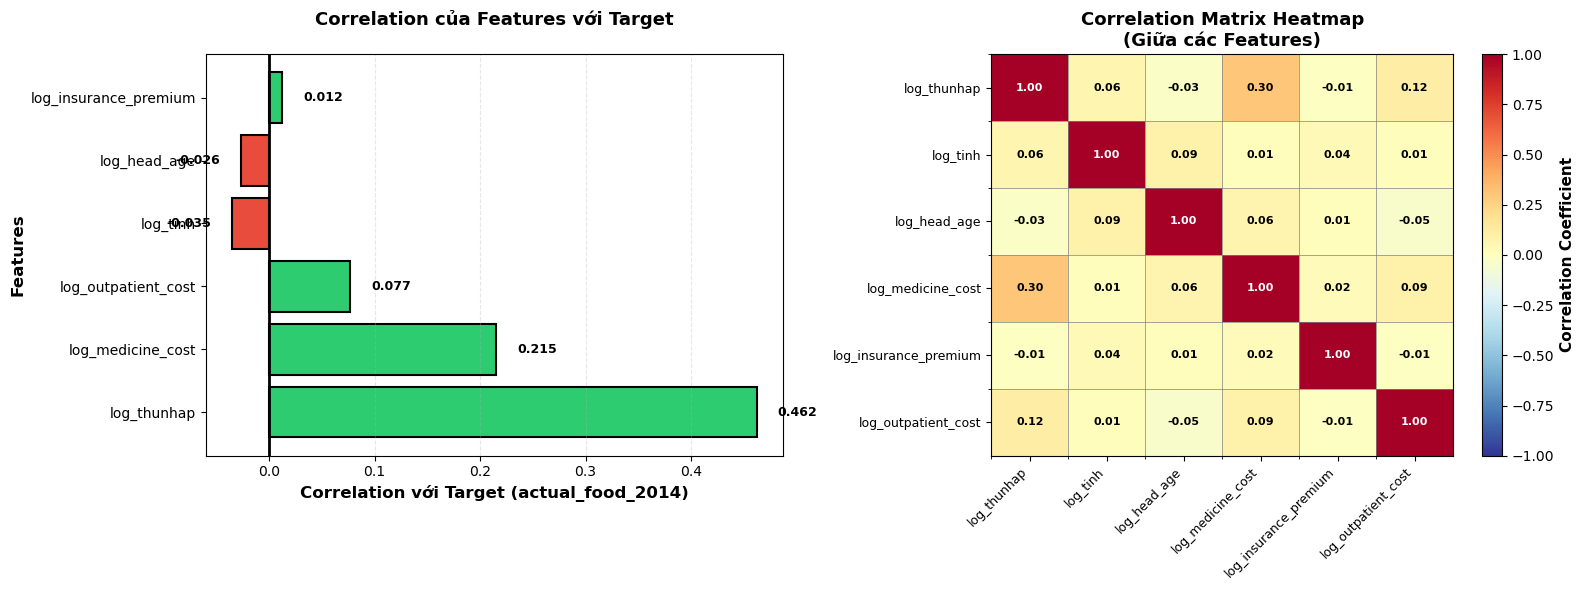

In [32]:
print(" PHÂN TÍCH CORRELATION")
X_train = train_df_selected.drop(['actual_food_14'], axis=1)
y_train = train_df_selected['actual_food_14']

print("\n[1] CORRELATION VỚI TARGET (actual_food_14)")

feature_target_corr = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation_with_Target': [X_train[col].corr(y_train) for col in X_train.columns]
}).sort_values('Correlation_with_Target', key=abs, ascending=False)

print("\n CORRELATION CỦA TỪNG FEATURE VỚI TARGET:")
print(feature_target_corr.to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ecc71' if x > 0 else '#e74c3c' 
          for x in feature_target_corr['Correlation_with_Target']]
bars = ax1.barh(feature_target_corr['Feature'], 
                feature_target_corr['Correlation_with_Target'],
                color=colors, edgecolor='black', linewidth=1.5)

ax1.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax1.set_xlabel('Correlation với Target (actual_food_2014)', 
               fontsize=12, fontweight='bold')
ax1.set_ylabel('Features', fontsize=12, fontweight='bold')
ax1.set_title('Correlation của Features với Target\n',
              fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, val) in enumerate(zip(bars, feature_target_corr['Correlation_with_Target'])):
    x_pos = val + (0.02 if val > 0 else -0.02)
    ha = 'left' if val > 0 else 'right'
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', ha=ha, 
             fontsize=9, fontweight='bold')


print("\n[2] CORRELATION MATRIX (GIỮA CÁC FEATURES)")

corr_matrix = X_train.corr()

# Heatmap
im = ax2.imshow(corr_matrix, cmap='RdYlBu_r', aspect='auto', 
                vmin=-1, vmax=1)

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Correlation Coefficient', fontsize=11, fontweight='bold')

ax2.set_xticks(np.arange(len(corr_matrix.columns)))
ax2.set_yticks(np.arange(len(corr_matrix.columns)))
ax2.set_xticklabels(corr_matrix.columns, rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(corr_matrix.columns, fontsize=9)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        color = 'white' if abs(value) > 0.6 else 'black'
        ax2.text(j, i, f'{value:.2f}',
                ha='center', va='center', 
                color=color, fontsize=8, fontweight='bold')

ax2.set_title('Correlation Matrix Heatmap\n(Giữa các Features)',
              fontsize=13, fontweight='bold')

ax2.set_xticks(np.arange(len(corr_matrix.columns))-0.5, minor=True)
ax2.set_yticks(np.arange(len(corr_matrix.columns))-0.5, minor=True)
ax2.grid(which='minor', color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()



In [ ]:
print(" CHUẨN BỊ DỮ LIỆU TRAINING/TEST")# Tạo X và y cho training (2014)X_train = train_df_selected.drop(['actual_food_14'], axis=1)y_train = train_df_selected['actual_food_14'].copy()# Tạo X và y cho testing (2016)X_test = test_df_selected.drop(['actual_food_16'], axis=1)y_test = test_df_selected['actual_food_16'].copy()print(f" X_train shape: {X_train.shape}")print(f" X_test shape:  {X_test.shape}")print(f" y_train shape: {y_train.shape}")print(f" y_test shape:  {y_test.shape}")print(f"\nKiểm tra dữ liệu")print(f"  X_train missing values: {X_train.isnull().sum().sum()}")print(f"  X_test missing values:  {X_test.isnull().sum().sum()}")print(f"  y_train missing values: {y_train.isnull().sum()}")print(f"  y_test missing values:  {y_test.isnull().sum()}")if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:    print("\n CẢNH BÁO: Vẫn còn missing values! Đang xử lý")    X_train.fillna(X_train.mean(), inplace=True)    X_test.fillna(X_train.mean(), inplace=True)     print("  Đã xử lý bằng mean từ train")

In [ ]:
print("\n STANDARDIZATION")
from sklearn.preprocessing import StandardScaler

# Fit scaler trên TRAIN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

# Convert về DataFrame để giữ tên cột
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"   Đã standardize X_train: mean ≈ 0, std ≈ 1")
print(f"   Đã standardize X_test bằng scaler từ train")

In [ ]:
print("TRAINING MODELS")

# MODEL 1: RANDOM FOREST
print("\n[1] RANDOM FOREST")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print(" Training")
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"   Training hoàn thành")
print(f"   R² Score:  {r2_rf:.4f}")
print(f"   RMSE:      {rmse_rf:,.0f} VNĐ")
print(f"   MAE:       {mae_rf:,.0f} VNĐ")


# MODEL 2: LINEAR REGRESSION
print("\n[2] LINEAR REGRESSION")
lr_model = LinearRegression()

print(" Training")
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"   Training hoàn thành")
print(f"   R² Score:  {r2_lr:.4f}")
print(f"   RMSE:      {rmse_lr:,.0f} VNĐ")
print(f"   MAE:       {mae_lr:,.0f} VNĐ")

In [ ]:
print("SO SÁNH VÀ ĐÁNH GIÁ MODELS")
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'R²': [r2_rf, r2_lr],
    'RMSE': [rmse_rf, rmse_lr],
    'MAE': [mae_rf, mae_lr],
    'Features Used': [X_train.shape[1], X_train.shape[1]]
})

print("\n BẢNG SO SÁNH MODELS:")
print(comparison_df.to_string(index=False))

# Xác định model tốt nhất
best_model_name = 'Random Forest' if r2_rf > r2_lr else 'Linear Regression'
best_r2 = max(r2_rf, r2_lr)
best_rmse = min(rmse_rf, rmse_lr)

print(f"\n MODEL TỐT NHẤT: {best_model_name}")
print(f"   R² Score:  {best_r2:.4f}")
print(f"   RMSE:      {best_rmse:,.0f} VNĐ")

In [ ]:
print("PHÂN TÍCH GROWTH RATE (2014 → 2016)")

# Tính log difference
log_2014 = np.log(y_train)  
log_2016 = np.log(y_test)    
log_diff_actual = log_2016 - log_2014

mean_diff = log_diff_actual.mean()
median_diff = log_diff_actual.median()
std_diff = log_diff_actual.std()

print("\n LOG DIFFERENCE ANALYSIS (Actual)")
print(f"  Mean log difference:   {mean_diff:.4f}")
print(f"  Median log difference: {median_diff:.4f}")
print(f"  Std log difference:    {std_diff:.4f}")
print(f"\n  → Average growth rate: {(np.exp(mean_diff) - 1) * 100:.2f}%")

# Predicted growth rates
log_pred_rf = np.log(y_pred_rf)
log_diff_pred_rf = log_pred_rf - log_2014
mean_diff_rf = log_diff_pred_rf.mean()

log_pred_lr = np.log(y_pred_lr)
log_diff_pred_lr = log_pred_lr - log_2014
mean_diff_lr = log_diff_pred_lr.mean()

print("\n PREDICTED GROWTH RATES:")
print(f"  Random Forest:      {(np.exp(mean_diff_rf) - 1) * 100:.2f}%")
print(f"  Linear Regression:  {(np.exp(mean_diff_lr) - 1) * 100:.2f}%")

# So sánh
error_rf = abs((np.exp(mean_diff_rf) - 1) * 100 - (np.exp(mean_diff) - 1) * 100)
error_lr = abs((np.exp(mean_diff_lr) - 1) * 100 - (np.exp(mean_diff) - 1) * 100)

print(f"\n SAI SỐ DỰ ĐOÁN GROWTH RATE:")
print(f"  Random Forest:      {error_rf:.2f} percentage points")
print(f"  Linear Regression:  {error_lr:.2f} percentage points")

if error_rf < error_lr:
    print(f"\n  → Random Forest dự đoán growth rate chính xác hơn!")
else:
    print(f"\n  → Linear Regression dự đoán growth rate chính xác hơn!")


In [ ]:
print(" VISUALIZATION CHO GROWTH RATE ANALYSIS")

# Tính log differences
log_2014 = np.log(y_train)  
log_2016 = np.log(y_test)    
log_diff_actual = log_2016 - log_2014

log_pred_rf = np.log(y_pred_rf)
log_diff_pred_rf = log_pred_rf - log_2014

log_pred_lr = np.log(y_pred_lr)
log_diff_pred_lr = log_pred_lr - log_2014

# Tính metrics
mean_diff = log_diff_actual.mean()
mean_diff_rf = log_diff_pred_rf.mean()
mean_diff_lr = log_diff_pred_lr.mean()

actual_growth = (np.exp(mean_diff) - 1) * 100
rf_growth = (np.exp(mean_diff_rf) - 1) * 100
lr_growth = (np.exp(mean_diff_lr) - 1) * 100

fig = plt.figure(figsize=(18, 12))

# PLOT 1: Distribution RF vs Actual
ax1 = plt.subplot(2, 3, 1)
ax1.hist(log_diff_actual, bins=50, alpha=0.6, color='blue', 
         label='Actual', edgecolor='black', density=True)
ax1.axvline(mean_diff, color='blue', linestyle='--', linewidth=2, 
            label=f'Actual Mean: {mean_diff:.4f}')
ax1.hist(log_diff_pred_rf, bins=50, alpha=0.4, color='red', 
         label='RF Predicted', edgecolor='black', density=True)
ax1.axvline(mean_diff_rf, color='red', linestyle='--', linewidth=2,
            label=f'RF Mean: {mean_diff_rf:.4f}')
ax1.set_xlabel('Log Difference (log(2016) - log(2014))', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Log Differences\nActual vs Random Forest', 
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)

# PLOT 2: Distribution LR vs Actual
ax2 = plt.subplot(2, 3, 2)
ax2.hist(log_diff_actual, bins=50, alpha=0.6, color='blue', 
         label='Actual', edgecolor='black', density=True)
ax2.axvline(mean_diff, color='blue', linestyle='--', linewidth=2,
            label=f'Actual Mean: {mean_diff:.4f}')
ax2.hist(log_diff_pred_lr, bins=50, alpha=0.4, color='green', 
         label='LR Predicted', edgecolor='black', density=True)
ax2.axvline(mean_diff_lr, color='green', linestyle='--', linewidth=2,
            label=f'LR Mean: {mean_diff_lr:.4f}')
ax2.set_xlabel('Log Difference (log(2016) - log(2014))', fontsize=11, fontweight='bold')
ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Log Differences\nActual vs Linear Regression', 
              fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

# PLOT 3: Growth Rate Bar Chart
ax3 = plt.subplot(2, 3, 3)
models = ['Actual\nGrowth', 'Random\nForest', 'Linear\nRegression']
growth_rates = [actual_growth, rf_growth, lr_growth]
colors = ['blue', 'red', 'green']
bars = ax3.bar(models, growth_rates, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, rate in zip(bars, growth_rates):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.2f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_ylabel('Growth Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title('Average Growth Rate Comparison\n(2014 → 2016)', 
              fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, max(growth_rates) * 1.2)

# PLOT 4: Scatter RF
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(log_diff_actual, log_diff_pred_rf, alpha=0.5, s=20, color='red')
min_val = min(log_diff_actual.min(), log_diff_pred_rf.min())
max_val = max(log_diff_actual.max(), log_diff_pred_rf.max())
ax4.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Log Difference', fontsize=11, fontweight='bold')
ax4.set_ylabel('RF Predicted Log Difference', fontsize=11, fontweight='bold')
ax4.set_title('Random Forest: Actual vs Predicted\nLog Differences', 
              fontsize=12, fontweight='bold')
ax4.legend(loc='upper left', fontsize=9)
ax4.grid(True, alpha=0.3)

# PLOT 5: Scatter LR
ax5 = plt.subplot(2, 3, 5)
ax5.scatter(log_diff_actual, log_diff_pred_lr, alpha=0.5, s=20, color='green')
ax5.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect Prediction')
ax5.set_xlabel('Actual Log Difference', fontsize=11, fontweight='bold')
ax5.set_ylabel('LR Predicted Log Difference', fontsize=11, fontweight='bold')
ax5.set_title('Linear Regression: Actual vs Predicted\nLog Differences', 
              fontsize=12, fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.grid(True, alpha=0.3)

# PLOT 6: Error Comparison
ax6 = plt.subplot(2, 3, 6)
error_rf = abs(rf_growth - actual_growth)
error_lr = abs(lr_growth - actual_growth)
models_err = ['Random\nForest', 'Linear\nRegression']
errors = [error_rf, error_lr]
colors_err = ['red', 'green']
bars = ax6.bar(models_err, errors, color=colors_err, alpha=0.7, edgecolor='black', linewidth=2)

for bar, err in zip(bars, errors):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{err:.2f}\npp',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax6.set_ylabel('Absolute Error (percentage points)', fontsize=11, fontweight='bold')
ax6.set_title('Growth Rate Prediction Error\n(vs Actual Growth)', 
              fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')

best_model = 'Linear Regression' if error_lr < error_rf else 'Random Forest'
ax6.text(0.5, max(errors) * 0.8, 
         f'✓ {best_model}\npredicts better!',
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

# In summary
print("SUMMARY - GROWTH RATE ANALYSIS (2014 → 2016)")
print(f"Actual Growth:        {actual_growth:.2f}%")
print(f"RF Predicted:         {rf_growth:.2f}% (error: {error_rf:.2f}pp)")
print(f"LR Predicted:         {lr_growth:.2f}% (error: {error_lr:.2f}pp)")
print(f"\n→ {best_model} dự đoán growth rate chính xác hơn!")
